# Overview Of Deep Learning Model Results on Index to Outcome Events

This notebook goes over the following topics:
1. Preprocessing
2. Model Training
3. Evaluation for C-Index in each respective model

## Preprocessing Steps

1. **Split labels from features**
   - For both train and test DataFrames, set `y = ["timeDiff", "status"]` and drop these from the feature sets.

2. **Drop meta/identifier columns**
   - Remove `["id", "user", "pool", "Index Event", "Outcome Event", "type", "timestamp"]` from both train and test (ignore if missing).

3. **Detect categoricals and cap rare levels (fit on train, apply to test)**
   - Identify categorical columns from the **train** features.
   - Cast those columns to `object` in both train and test.
   - For each categorical column, keep the **top 10** categories based on train frequencies; replace all others with `"Other"` in both train and test.

4. **One-hot encode with train as the template**
   - Run `pd.get_dummies(..., columns=categorical_cols, dummy_na=True, drop_first=True)` separately on train and on test.
   - Reindex the test encoded matrix to match **train’s columns**, filling missing columns with `0`.

5. **Standardize numeric columns (fit on train, transform test)**
   - Select numeric columns from the encoded **train** set.
   - Fit `StandardScaler` on train numeric columns; transform test using the same scaler.
   - Wrap transformed arrays back into DataFrames and `fillna(0)`.

6. **Remove near-zero variance features (based on train variance)**
   - Keep columns where train variance `> min_var` (default `1e-5`) and apply the same column mask to test.

7. **(Training set only) Downsample censored rows to reach a minimum event ratio**
   - If event share (`status==1`) `< uncensored_ratio` (default `0.055`), keep all events and randomly keep just enough censored rows to meet the target ratio. Subset `X_train` and `y_train` accordingly.

8. **Filter invalid times and convert units**
   - Drop rows where `timeDiff <= 0` in both train and test.
   - Convert `timeDiff` from seconds to days by dividing by `86,400`.
   - This is done by simple division for both train and test sets.

9. **Feature selection with MRMR (training set only)**
   - Run `mrmr_classif(X_train, y=status, K=feature_count)` using `status` as the target.
   - Subset **both** `X_train` and `X_test` to the selected feature list.

10. **(Optional) Subsample the training data**
    - Randomly keep a fraction of training rows (`sample=0.95` by default) before splitting for evaluation.

11. **Create the evaluation split from the processed training set**
    - Use `train_test_split` to form `X_train_split / X_val_split / y_train_split / y_val_split` with `test_size=val_frac` (default `0.2`) and `stratify=y_train["status"]`.
    - Build arrays: `durations_* = y_*["timeDiff"].values` and `events_* = y_*["status"].astype(bool).values`.
    - **Note:** The **evaluation split** (train/val) is internal to the training data; the **test split** is the separate, final held-out dataset.

---

## Data Leakage & Other Notes

- **Leakage into evaluation split (val):**
  - Steps 3–6 and 9 (category capping, one-hot template, scaler fit, variance filter, MRMR selection) are fit on the **entire** training set **before** splitting into train/val, so val information influences these transforms.
  - This leakage may be fine because we don't leak into the test set and the evaluation split is part of train and only used for training and not evaluation.

- **No test leakage:**
  - All fitting is done on training data; the test set is only transformed, not used for fitting.

- **Randomness / reproducibility:**
  - Censored downsampling and optional subsampling use random sampling without a fixed seed; set a `random_state` for reproducibility.

- **Distribution shift due to downsampling:**
  - Adjusting the event ratio can help training but changes label prevalence vs. the real/test distribution. Consider class-balanced losses or weights as alternatives.

- **MRMR uses only `status`:**
  - Time-to-event information (`timeDiff`) is not used for feature selection; consider survival-aware filters if needed.
  - MRMR package found here: https://pypi.org/project/mrmr-selection/

- **Reminder on splits:**
  - **Evaluation split** = the internal train/val split used for tuning.
  - **Test split** = the final, held-out dataset used only for final evaluation.



In [ ]:
# DO NOT RUN THIS CODE. This is only used for demo purposes for this notebook.

import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import StandardScaler
from typing import Tuple, Optional
from mrmr import mrmr_classif
from sklearn.model_selection import train_test_split

def preprocess(
    train_df_with_labels: pd.DataFrame,
    test_df_with_labels: pd.DataFrame,
    uncensored_ratio: float = 0.055,
    min_var: float = 1e-5,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Preprocesses data for the benchmark.
    Now expects both train and test dataframes WITH labels (timeDiff, status).
    Returns: X_train, X_test, y_train, y_test
    """
    
    # ---- split targets / features (train) ----
    y_train = train_df_with_labels[["timeDiff", "status"]]
    train_features = train_df_with_labels.drop(columns=["timeDiff", "status"])

    # ---- split targets / features (test) ----
    y_test = test_df_with_labels[["timeDiff", "status"]]
    test_features = test_df_with_labels.drop(columns=["timeDiff", "status"])

    # ---- drop meta cols (same as before) ----
    cols_to_drop = ["id", "user", "pool", "Index Event", "Outcome Event", "type", "timestamp"]
    train_features = train_features.drop(columns=cols_to_drop, errors="ignore")
    test_features  = test_features.drop(columns=cols_to_drop,  errors="ignore")

    # ---- handle categoricals (fit on train, apply to test) ----
    categorical_cols = train_features.select_dtypes(include=["object", "category"]).columns
    # Ensure all categorical columns are treated as object for replacement
    train_features[categorical_cols] = train_features[categorical_cols].astype("object")
    test_features[categorical_cols]  = test_features[categorical_cols].astype("object")

    for col in categorical_cols:
        top_categories = train_features[col].value_counts().nlargest(10).index
        train_features[col] = train_features[col].where(train_features[col].isin(top_categories), "Other")
        # apply same capping to test
        test_features[col] = test_features[col].where(test_features[col].isin(top_categories), "Other")

    # ---- one-hot encode (train as template) ----
    train_features_encoded = pd.get_dummies(
        train_features, columns=categorical_cols, dummy_na=True, drop_first=True
    )
    test_features_encoded = pd.get_dummies(
        test_features, columns=categorical_cols, dummy_na=True, drop_first=True
    )

    # Align test to train columns (fill missing with 0)
    train_cols = train_features_encoded.columns
    test_features_aligned = test_features_encoded.reindex(columns=train_cols, fill_value=0)

    # ---- scale numeric columns (fit on train, apply to test) ----
    numerical_cols = train_features_encoded.select_dtypes(include=np.number).columns
    scaler = StandardScaler()
    train_features_scaled = scaler.fit_transform(train_features_encoded[numerical_cols])
    test_features_scaled  = scaler.transform(test_features_aligned[numerical_cols])

    # Rewrap as DataFrames and fill any residual NaNs with 0 (as before)
    X_train = pd.DataFrame(
        train_features_scaled, index=train_features_encoded.index, columns=numerical_cols
    ).fillna(0)
    X_test = pd.DataFrame(
        test_features_scaled, index=test_features_aligned.index, columns=numerical_cols
    ).fillna(0)

    # ---- drop zero-variance columns based on train; apply same mask to test ----
    cols_to_keep = X_train.columns[X_train.var() > min_var]
    X_train = X_train[cols_to_keep]
    X_test  = X_test[cols_to_keep]
    
    # ---- balance training data so events make up >= 10% ----
    event_mask = y_train["status"] == 1
    cens_mask  = y_train["status"] == 0

    event_count = event_mask.sum()
    cens_count  = cens_mask.sum()
    total = len(y_train)
    current_ratio = event_count / total

    target_ratio = uncensored_ratio  # desired minimum share of events
    if event_count == 0:
        raise ValueError("No events in training data. Cannot downsample censored.")

    if current_ratio < target_ratio and event_count > 0:
        # compute number of censored samples to keep
        max_cens_to_keep = int(event_count * (1 - target_ratio) / target_ratio)
        max_cens_to_keep = min(max_cens_to_keep, cens_count)
        
        keep_cens_idx = np.random.choice(
            y_train[cens_mask].index,
            size=max_cens_to_keep,
            replace=False
        )
        keep_idx = np.concatenate([y_train[event_mask].index, keep_cens_idx])

        X_train = X_train.loc[keep_idx].reset_index(drop=True)
        y_train = y_train.loc[keep_idx].reset_index(drop=True)
        
        new_ratio = y_train["status"].mean()
        print(f"[dbg] Downsampled censored: {cens_count} → {max_cens_to_keep}, "
            f"event ratio: {new_ratio:.3f}")
    else:
        print(f"[dbg] Skipped downsampling (event ratio {current_ratio:.3f} ≥ {target_ratio})")
        
    # ---- clean up survival targets ----
    SECONDS_IN_DAY = 86400
    mask_train = y_train["timeDiff"] > 0
    mask_test  = y_test["timeDiff"] > 0

    X_train = X_train.loc[mask_train].reset_index(drop=True)
    y_train = y_train.loc[mask_train].reset_index(drop=True)

    X_test  = X_test.loc[mask_test].reset_index(drop=True)
    y_test  = y_test.loc[mask_test].reset_index(drop=True)

    y_train["timeDiff"] /= SECONDS_IN_DAY
    y_test["timeDiff"]  /= SECONDS_IN_DAY
    return X_train, X_test, y_train, y_test

def prepare_sample_datasets_mrmr(index, outcome, sample=0.95, val_frac=0.2, feature_count=30, datasets=None):
    train_df, test_df = datasets[(index, outcome)]
    X_train, X_test, y_train, y_test = preprocess(train_df, test_df)

    # ---- MRMR feature selection ----
    target_for_fs = y_train["status"].astype(int).values
    selected_features = mrmr_classif(X=X_train, y=target_for_fs, K=feature_count)
    print("Selected features:", selected_features)

    # Subset both train and test
    X_train = X_train[selected_features]
    X_test  = X_test[selected_features]

    # ---- optional: downsample train ----
    train_idx = np.random.choice(len(X_train), math.floor(len(X_train) * sample), replace=False)
    X_train = X_train.iloc[train_idx].reset_index(drop=True)
    y_train = y_train.iloc[train_idx].reset_index(drop=True)

    # ---- split train into train/val (80/20 by default) ----
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train, y_train, test_size=val_frac, random_state=42, stratify=y_train["status"]
    )

    # ---- final safety: rebuild arrays ----
    durations_train = y_train_split["timeDiff"].values
    events_train    = y_train_split["status"].values.astype(bool)

    durations_val   = y_val_split["timeDiff"].values
    events_val      = y_val_split["status"].values.astype(bool)

    durations_test  = y_test["timeDiff"].values
    events_test     = y_test["status"].values.astype(bool)

    print("Train shape:", X_train_split.shape, y_train_split.shape)
    print("Val shape:", X_val_split.shape, y_val_split.shape)
    print("Test shape:", X_test.shape, y_test.shape)
    print("Train durations (days): min", durations_train.min(), "max", durations_train.max())
    print("Val durations (days): min", durations_val.min(), "max", durations_val.max())
    print("Test durations (days): min", durations_test.min(), "max", durations_test.max())

    return (
        X_train_split, y_train_split,
        X_val_split, y_val_split,
        X_test, y_test,
        durations_train, events_train,
        durations_val, events_val,
        durations_test, events_test
    )

## Model Training and Parameter Selection

We conducted neural survival model training using two architectures: **DeepSurv (CoxPH)** for continuous-time survival modeling and **DeepHitSingle** for discrete-time modeling. Both models were implemented with the `MLPVanilla` network from *pycox*, which constructs a fully-connected feed-forward multilayer perceptron with optional dropout and batch normalization between layers.

### Hyperparameter Search Space
A random search procedure explored the following ranges:

- **Number of layers:** 2 – 18  
- **Hidden layer size:** {16, 32, 64, 128, 256, 512}  
- **Dropout rate:** 0.0 – 0.5  
- **Batch size:** {256, 512, 1024, 2048, 4096}  
- **Learning rate:** {1e-4, 5e-4, 1e-3, 1e-5,5e-5} (adjusted by depth)  
- **Weight decay:** {0, 1e-5, 1e-4, 1e-3}  
- **Batch normalization:** always enabled  
- **Optimizer:** {Adam, AdamW, RMSprop}  
- **Activation functions:** depth-dependent selection from ReLU, LeakyReLU, ELU, SiLU, GELU, Tanh  

Deeper networks used smaller learning rates and more epochs (≈10) to ensure convergence, while shallower networks trained for fewer epochs (≈5).  
Gradient clipping was conditionally applied based on network depth, activation choice, and optimizer type to prevent exploding gradients.

### Model Architectures and Loss Functions
- **DeepSurv (CoxPH):**  
  - Built on the proportional hazards assumption.  
  - Cox proportional hazards model parameterized with a neural net.
  - According to PyCox library: This is essentially the DeepSurv method [1]. The loss function is not quite the partial log-likelihood, but close. The difference is that for tied events, we use a random order instead of including all individuals that had an event at that point in time.
  - Produces a *risk score* proportional to log-hazard, allowing direct computation of concordance index (C-index) for evaluation.
  - For information available here: https://github.com/havakv/pycox/blob/master/pycox/models/cox.py

- **DeepHitSingle:**  
  - Discretizes time into `N` intervals (default = 100).  
  - Optimizes a weighted combination of **negative log-likelihood** and **ranking loss**:
    where α = 0.2 and σ = 0.1 by default.
  - More information on loss function available here: 
  - Generates a discrete survival probability mass function over time bins, enabling time-dependent concordance via Antolini’s metric.

In [ ]:
# DO NOT RUN THIS CODE. IT WILL NOT WORK. THIS IS SAMPLE CODE FROM THE FILE.

# defining the hyperparameter search space
search_space = {
    "num_layers": [2, 3, 4, 5,6,7,8,9,10,12,16,18],
    "hidden_sizes": [16, 32, 64, 128, 256,512],
    "dropout": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "batch_size": [256, 512, 1024, 2048, 4096],
    "learning_rate": [1e-4, 5e-4, 1e-3, 5e-4],
    "weight_decay": [0.0, 1e-5, 1e-4, 1e-3],
    "batch_norm": [True],
    "optimizer": ["Adam", "AdamW", "RMSprop"],  # sampled as string
}


def sample_config():
    num_layers = random.choice(search_space["num_layers"])
    hidden_sizes = ([random.choice(search_space["hidden_sizes"]) for _ in range(num_layers)])
    
    config = {
        "hidden_sizes": hidden_sizes,
        "dropout": random.choice(search_space["dropout"]),
        "batch_size": random.choice(search_space["batch_size"]),
        "weight_decay": random.choice(search_space["weight_decay"]),
        "batch_norm": random.choice(search_space["batch_norm"]),
        "optimizer": random.choice(search_space["optimizer"]),  # e.g., Adam, AdamW, RMSprop
        "num_layers": num_layers,
    }
    
    # if layers are small, you can afford a larger learning rate
    if num_layers <= 6:
        config["learning_rate"] = random.choice([1e-3, 5e-4, 1e-4])
        config["epochs"] = 5  # fewer epochs for shallower nets
    else:
        config["learning_rate"] = random.choice([5e-4, 1e-4, 5e-5, 1e-5])
        config["epochs"] = 10  # more epochs for deeper nets and slower learning rates
        
    # choose activation based on depth
    if num_layers <= 3:
        allowed_acts = [torch.nn.ReLU, torch.nn.Tanh, torch.nn.LeakyReLU]
    elif num_layers <= 8:
        allowed_acts = [torch.nn.ReLU, torch.nn.LeakyReLU, torch.nn.ELU, torch.nn.SiLU, torch.nn.GELU]
    else:
        # Very deep nets → avoid saturating activations (Tanh, ELU) due to vanishing gradients
        allowed_acts = [torch.nn.ReLU, torch.nn.LeakyReLU, torch.nn.SiLU, torch.nn.GELU]

    config["activation"] = random.choice(allowed_acts)

    return config

def decide_clip_grad(config):
    # decide whether to use gradient clipping
    use_clip = False
    clip_value = None
    
    num_layers = config["num_layers"]+2
    activation = config["activation"]
    batch_norm = config["batch_norm"]
    learning_rate = config["learning_rate"]
    optimizer = config["optimizer"]
    batch_size = config["batch_size"]

    # ---- 1. Depth-based rule ----
    if num_layers >= 8:
        use_clip = True
        clip_value = 1.0  # deeper nets → more likely to explode

    # ---- 2. Activation-based rule ----
    if activation in [torch.nn.ReLU, torch.nn.LeakyReLU, torch.nn.ELU]:
        # these are unbounded → higher risk
        use_clip = True
        clip_value = clip_value or 1.0  # ensure it's at least 1.0

    if activation in [torch.nn.SELU, torch.nn.Tanh]:
        # tend to shrink gradients, so less need for clipping
        if num_layers < 10:
            use_clip = False

    # ---- 3. BatchNorm rule ----
    if batch_norm:
        # BatchNorm stabilizes activations → less need to clip unless network is very deep
        if num_layers < 12:
            use_clip = False

    # ---- 4. Learning rate rule ----
    if learning_rate >= 5e-4:
        # aggressive learning rate → higher chance of exploding gradients
        use_clip = True
        clip_value = clip_value or 1.0

    # ---- 5. Optimizer rule ----
    if optimizer == "RMSprop":
        # RMSprop can overreact to spikes; clipping helps
        use_clip = True
        clip_value = clip_value or 1.0

    # ---- 6. Batch size rule ----
    if batch_size < 512:
        # smaller batch = noisier gradients
        use_clip = True
        clip_value = clip_value or 0.5
        
    return use_clip, clip_value


def train_and_eval(config, X_train_split, X_val_split, X_test, durations_train, durations_val, durations_test, events_train, events_val, events_test):
    in_features = X_train_split.shape[1]
    net = tt.practical.MLPVanilla(
        in_features, 
        config["hidden_sizes"], 
        out_features=1,
        batch_norm=config["batch_norm"],
        dropout=config["dropout"],
        activation=config["activation"]
    ).to("cuda")

    if config["optimizer"] == "Adam":
        model = CoxPH(net, tt.optim.Adam)
    elif config["optimizer"] == "AdamW":
        model = CoxPH(net, torch.optim.AdamW)
    elif config["optimizer"] == "RMSprop":
        model = CoxPH(net, torch.optim.RMSprop)

    # Apply LR and weight decay if supported
    if hasattr(model.optimizer, "set_lr"):
        model.optimizer.set_lr(config["learning_rate"])
    if hasattr(model.optimizer, "set_weight_decay"):
        model.optimizer.set_weight_decay(config["weight_decay"])
        
    #CHANGED THIS LINE
    if hasattr(model.optimizer, "clip_grad_norm"):
        model.optimizer.clip_grad_norm = 1.0  # prevents gradient explosion

    log = model.fit(
        X_train_split.values.astype("float32"),
        (durations_train, events_train),
        batch_size=config["batch_size"],
        epochs=config.get("epochs", 5),
        val_data=(X_val_split.values.astype("float32"), (durations_val, events_val)),
        verbose=False,
        num_workers=16,
    )

    # Risk scores & c-index
    try:
        risk_scores = -model.predict(X_test.values.astype("float32"))
        risk_scores = risk_scores.flatten()  # ensure 1D array
        c_index = concordance_index(durations_test, risk_scores, events_test)

    except Exception as e:
        import traceback
        print("\n[ERROR] Failed to compute c-index.")
        print("Exception:", type(e).__name__, "-", e)
        traceback.print_exc()

        # Optional: Save failed batch to inspect later
        debug_info = {
            "risk_scores_nan": np.isnan(risk_scores).any() if "risk_scores" in locals() else None,
            "risk_scores_inf": np.isinf(risk_scores).any() if "risk_scores" in locals() else None,
            "durations_nan": np.isnan(durations_test).any(),
            "events_nan": np.isnan(events_test).any(),
            
        }
        print("Debug info:", debug_info)

        # Default to NaN score so loop continues
        c_index = -1

    return c_index, config

def train_and_eval_deephit(config, X_train_split, X_val_split, X_test, durations_train, durations_val, durations_test, events_train, events_val, events_test, num_durations=100):
    # 1) Discretize time with N bins (automatic, sorted)
    labtrans = DeepHitSingle.label_transform(num_durations)
    y_train_dh = labtrans.fit_transform(durations_train, events_train)
    y_val_dh   = labtrans.transform(durations_val,  events_val)
    duration_index = labtrans.cuts

    # 2) Net
    in_features = X_train_split.shape[1]
    net = tt.practical.MLPVanilla(
        in_features,
        config["hidden_sizes"],
        out_features=labtrans.out_features,
        batch_norm=config["batch_norm"],
        dropout=config["dropout"],
        activation=config["activation"],
    ).to("cuda")

    # 3) Model
    if config["optimizer"] == "Adam":
        model = DeepHitSingle(net, tt.optim.Adam, duration_index=duration_index)
    elif config["optimizer"] == "AdamW":
        model = DeepHitSingle(net, torch.optim.AdamW, duration_index=duration_index)
    else:
        model = DeepHitSingle(net, torch.optim.RMSprop, duration_index=duration_index)

    if hasattr(model.optimizer, "set_lr"):
        model.optimizer.set_lr(config["learning_rate"])
    if hasattr(model.optimizer, "set_weight_decay"):
        model.optimizer.set_weight_decay(config["weight_decay"])
        
    use_clip, clip_value = decide_clip_grad(config)
    if use_clip:
        if hasattr(model.optimizer, "clip_grad_norm"):
            model.optimizer.clip_grad_norm = clip_value
    config["clip_grad"] = use_clip
    config["clip_value"] = clip_value

    # 4) Fit
    log = model.fit(
        X_train_split.values.astype("float32"),
        y_train_dh,
        batch_size=config["batch_size"],
        epochs=config.get("epochs", 5),
        val_data=(X_val_split.values.astype("float32"), y_val_dh),
        verbose=False,
        num_workers=16,
    )
    print("Finish fitting DeepHitSingle Model")

    # 5) Predict + Antolini
    surv = model.predict_surv_df(X_test.values.astype("float32"))
    print("Finished predicting survival function")
    t_idx = surv.index.values
    durations_test_clipped = np.clip(durations_test, t_idx.min(), t_idx.max())
    ev = EvalSurv(surv, durations_test_clipped, events_test, censor_surv="km")
    c_index = ev.concordance_td("antolini")
    return c_index, config

## Evaluation

Information on Risk Scores: https://github.com/havakv/pycox/issues/33
Information on DeepHit Evaluation:
- https://github.com/havakv/pycox/blob/master/pycox/models/deephit.py
- https://nbviewer.org/github/havakv/pycox/blob/master/examples/deephit.ipynb

## Evaluation
Model performance was evaluated using **concordance-based metrics**, which measure how well the model preserves the ordering of event times.

- **For DeepSurv (CoxPH):**  
  The model’s `predict()` output represents the **risk score** (log-hazard ratio).  
  Predictions were inverted (i.e., `-risk_score`) before computing the **Concordance Index (C-index)** using `lifelines.utils.concordance_index`.  
  This metric quantifies how often predicted risks correctly rank event times across individuals.

- **For DeepHitSingle:**  
  The model predicts a **discrete survival probability function** over a fixed set of time bins.  
  The **Antolini C-index** was computed using `pycox.evaluation.EvalSurv`, which compares predicted survival probabilities with observed durations and censoring.  
  This discrete-time version accounts for ties and censored observations appropriately.

In both cases, the C-index reflects the proportion of correctly ordered event pairs, with values closer to 1 indicating stronger concordance between predicted and actual survival ordering.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = "results"
INDEX_EVENTS = ["Borrow", "Repay", "Deposit", "Withdraw"]
OUTCOME_EVENTS = ["Borrow", "Repay", "Deposit", "Withdraw", "Account Liquidated"]

os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
def load_all_results(data_dir=DATA_DIR):
    json_files = [f for f in os.listdir(data_dir) if f.endswith(".json")]
    all_data = {}

    for jf in json_files:
        path = os.path.join(data_dir, jf)
        print(path)
        with open(path, "r") as f:
            data = json.load(f)
        index_name = data.get("index", jf.replace("DEEPSURV_", "").replace(".json", ""))
        all_data[index_name.lower()] = data
    return all_data

def extract_best_trials(results_dict):
    best_records = []

    for index, content in results_dict.items():
        for outcome, trials in content["trials"].items():
            if not trials:
                continue
            df = pd.DataFrame(trials)
            df["index_event"] = index.title()
            df["outcome_event"] = outcome.title()

            best_row = df.loc[df["c_index"].idxmax()]
            best_records.append(best_row)

    best_df = pd.DataFrame(best_records)
    return best_df

In [3]:
def plot_cindex_scores(data_dir=None):
    results_data = load_all_results(data_dir)
    best_trials_df = extract_best_trials(results_data)
    pivot_df = best_trials_df.pivot_table(
        index="index_event", columns="outcome_event", values="c_index"
    )
    pivot_df = pivot_df.reindex(index=INDEX_EVENTS, columns=OUTCOME_EVENTS)
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        linewidths=0.5,
        cbar_kws={"label": "C-index"},
    )
    plt.title("C-index Across Index and Outcome Events (Best Config per Pair)")
    plt.ylabel("Index Event")
    plt.xlabel("Outcome Event")
    plt.tight_layout()
    plt.show()

results/deephit/deephit_repay.json
results/deephit/deephit_deposit.json
results/deephit/deephit_withdraw.json
results/deephit/deephit_borrow.json


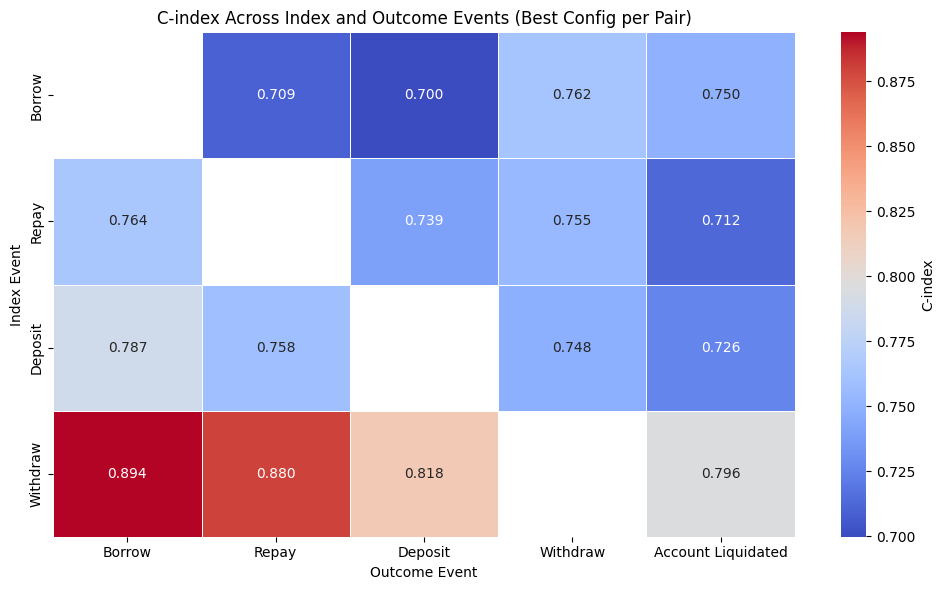

In [4]:
plot_cindex_scores(data_dir="results/deephit")

results/deepsurv/DEEPSURV_deposit.json
results/deepsurv/DEEPSURV_withdraw.json
results/deepsurv/DEEPSURV_borrow.json
results/deepsurv/DEEPSURV_repay.json


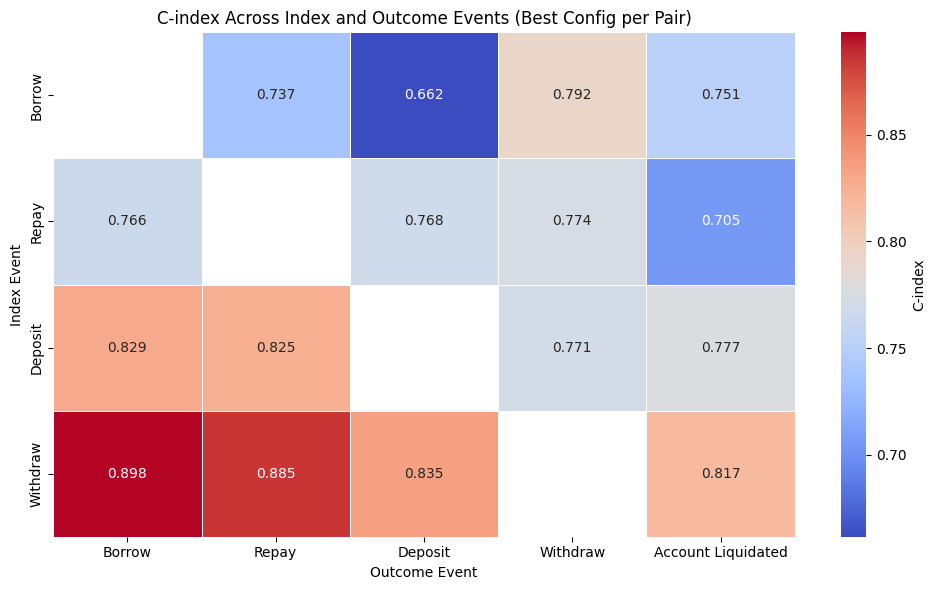

In [5]:
plot_cindex_scores(data_dir="results/deepsurv")